# Spotify Track Ranking Project

This work focuses on constructing a track rating framework based on Spotify audio feature vectors and popularity indices. By applying a feature-weighted scoring algorithm, the model systematically identifies and extracts the top-ranked tracks within the dataset.

<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSaC-0cWLKjwxq6kgAm1kCInqPBR3m9s0Lypu2K8BQS8Q&s=10' width='750'>

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# EDA 

In [2]:
df=pd.read_csv('dataset.csv')

In [3]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.tail()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,...,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,...,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,...,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,...,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,...,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [5]:
df.shape

(114000, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [7]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [8]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [9]:
df['track_genre'].value_counts()

track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
                     ... 
folk                 1000
emo                  1000
electronic           1000
electro              1000
world-music          1000
Name: count, Length: 114, dtype: int64

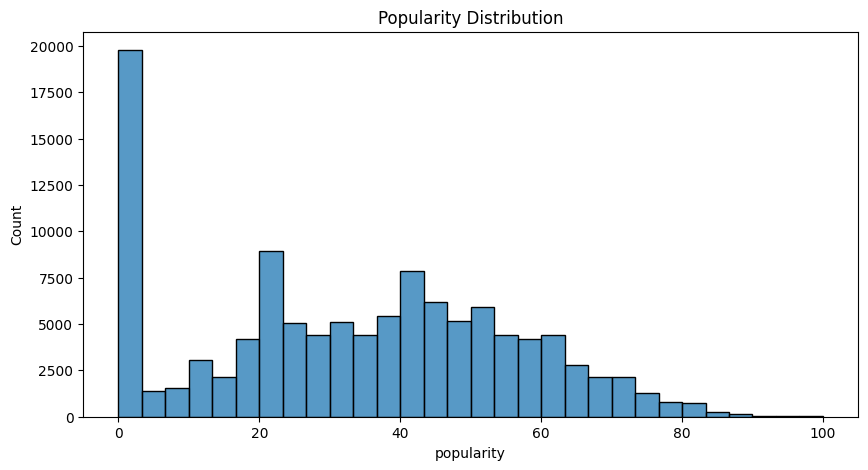

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df['popularity'], bins=30)
plt.title("Popularity Distribution")
plt.show()

In [12]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [13]:
df = df[['track_name', 'artists', 'track_genre', 'popularity','danceability', 'energy', 'valence', 'tempo']]

In [15]:
df = df.dropna()

In [17]:
df.columns

Index(['track_name', 'artists', 'track_genre', 'popularity', 'danceability',
       'energy', 'valence', 'tempo'],
      dtype='object')

In [19]:
df.shape

(113999, 8)

In [20]:
df.isnull().sum()


track_name      0
artists         0
track_genre     0
popularity      0
danceability    0
energy          0
valence         0
tempo           0
dtype: int64

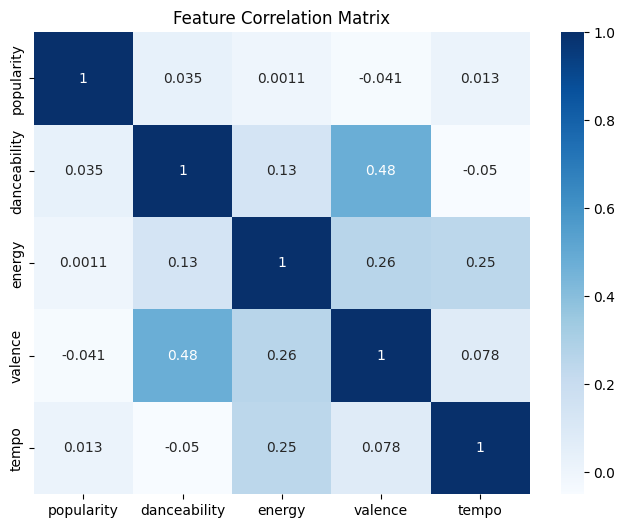

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['popularity', 'danceability', 'energy', 'valence', 'tempo']].corr(), annot=True, cmap='Blues')
plt.title("Feature Correlation Matrix")
plt.show()

### Ranking Model

In [22]:
df['score'] = (0.40 * df['popularity'] +0.20 * (df['danceability'] * 100) +0.20 * (df['energy'] * 100) +0.20 * (df['valence'] * 100))

In [24]:
ranked_df = df.sort_values('score', ascending=False)

In [25]:
ranked_df.head()


,track_name,artists,track_genre,popularity,danceability,energy,valence,tempo,score
51458,Super Freaky Girl,Nicki Minaj,hip-hop,92,0.950,0.891,0.912,133.010,91.86
20410,Super Freaky Girl,Nicki Minaj,dance,92,0.950,0.891,0.912,133.010,91.86
20924,Super Freaky Girl,Nicki Minaj,dance,83,0.951,0.878,0.923,133.014,88.24
51261,That That (prod. & feat. SUGA of BTS),PSY;SUGA,hip-hop,81,0.905,0.962,0.906,129.969,87.86
20028,There's Nothing Holdin' Me Back,Shawn Mendes,dance,86,0.866,0.813,0.969,121.998,87.36


In [26]:
### Top Ranked Songs

In [27]:
ranked_df[['track_name', 'artists', 'track_genre', 'popularity', 'score']].head(10)

,track_name,artists,track_genre,popularity,score
51458,Super Freaky Girl,Nicki Minaj,hip-hop,92,91.86
20410,Super Freaky Girl,Nicki Minaj,dance,92,91.86
20924,Super Freaky Girl,Nicki Minaj,dance,83,88.24
51261,That That (prod. & feat. SUGA of BTS),PSY;SUGA,hip-hop,81,87.86
20028,There's Nothing Holdin' Me Back,Shawn Mendes,dance,86,87.36
81192,There's Nothing Holdin' Me Back,Shawn Mendes,pop,86,87.36
88410,La Bachata,Manuel Turizo,reggae,98,86.48
68303,La Bachata,Manuel Turizo,latino,98,86.48
67356,La Bachata,Manuel Turizo,latin,98,86.48
89411,La Bachata,Manuel Turizo,reggaeton,98,86.48


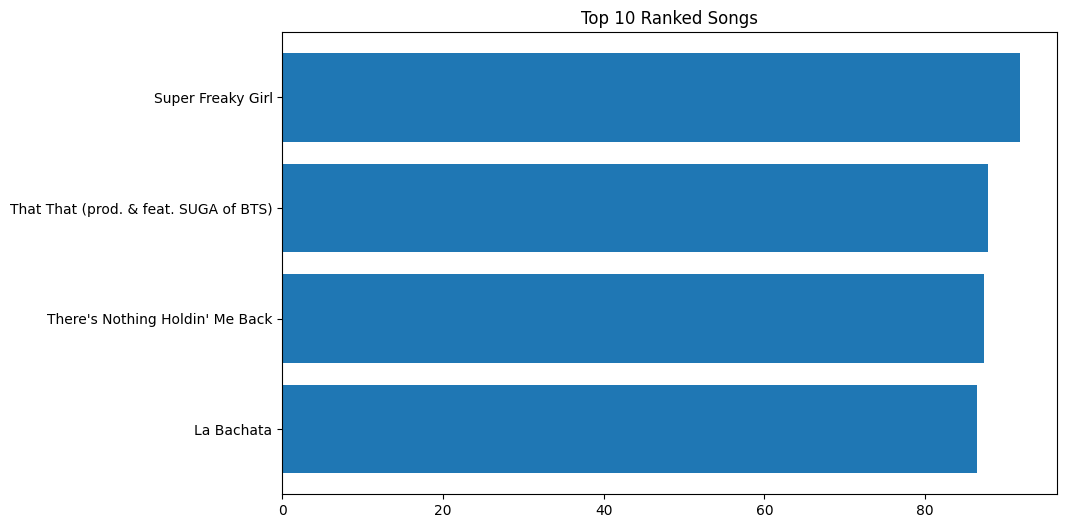

In [28]:
top10 = ranked_df[['track_name', 'score']].head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['track_name'], top10['score'])
plt.title("Top 10 Ranked Songs")
plt.gca().invert_yaxis()
plt.show()

### Genre Based Recommendation

In [29]:
def recommend_by_genre(genre, top_n=10):
    
    genre_df = ranked_df[ranked_df['track_genre'] == genre]
    
    return genre_df[['track_name','artists','track_genre','score']].head(top_n)

In [31]:
recommend_by_genre("pop")

,track_name,artists,track_genre,score
81192,There's Nothing Holdin' Me Back,Shawn Mendes,pop,87.36
81143,Bad Decisions (with BTS & Snoop Dogg),benny blanco;BTS;Snoop Dogg,pop,86.36
81100,Calm Down (with Selena Gomez),Rema;Selena Gomez,pop,84.98
81174,I Ain't Worried,OneRepublic,pop,84.92
81155,Woman,Doja Cat,pop,84.58
81124,Levitating,Dua Lipa,pop,83.46
81250,Levitating (feat. DaBaby),Dua Lipa;DaBaby,pop,82.84
81031,Shape of You,Ed Sheeran,pop,82.56
81219,What Makes You Beautiful,One Direction,pop,81.62
81874,"1, 2, 3 (feat. Jason Derulo & De La Ghetto)",Sofía Reyes;Jason Derulo;De La Ghetto,pop,81.22


In [33]:
recommend_by_genre("rock")

,track_name,artists,track_genre,score
91003,I Ain't Worried,OneRepublic,rock,84.92
91151,Cold Heart - PNAU Remix,Elton John;Dua Lipa;PNAU,rock,83.78
91722,Sultans Of Swing,Dire Straits,rock,81.56
91455,Pumped Up Kicks,Foster The People,rock,81.36
91853,Take on Me,a-ha,rock,81.02
91405,Cloud 9,Beach Bunny,rock,80.96
91803,I'm In Love With You,The 1975,rock,80.86
91154,Sunshine,OneRepublic,rock,80.12
91511,"Hey, Soul Sister",Train,rock,79.88
91011,Believer,Imagine Dragons,rock,79.64


In [34]:
recommend_by_genre("hip-hop")

,track_name,artists,track_genre,score
51458,Super Freaky Girl,Nicki Minaj,hip-hop,91.86
51261,That That (prod. & feat. SUGA of BTS),PSY;SUGA,hip-hop,87.86
51216,The Real Slim Shady,Eminem,hip-hop,82.20
51369,Not Afraid,Eminem,hip-hop,81.94
51352,About Damn Time,Lizzo,hip-hop,81.62
51043,"Private Party (From ""Don"")",Anirudh Ravichander;Jonita Gandhi,hip-hop,81.28
51050,INDUSTRY BABY (feat. Jack Harlow),Lil Nas X;Jack Harlow,hip-hop,81.08
51652,In Da Club,50 Cent,hip-hop,80.98
51320,Godzilla (feat. Juice WRLD),Eminem;Juice WRLD,hip-hop,80.84
51044,"Pathala Pathala (From ""Vikram"")",Anirudh Ravichander;Kamal Haasan,hip-hop,80.42


This project presents a lightweight, interpretable music recommendation system that ranks Spotify tracks using popularity and core audio characteristics. With built-in genre filtering, the model offers a simple yet powerful approach to personalized track discovery.